In [ ]:
%pip -q install pretty_midi mido tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 54.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import zipfile
import shutil
from pathlib import Path
import pandas as pd

task3_zip_path = Path("/content/drive/MyDrive/CSE425_Project/task3_outputs/CSE425_Task3_Transformer_Music_Generator.zip")

task4_root = Path("/content/drive/MyDrive/CSE425_Project")
survey_folder = task4_root / "task4_survey" / "before_samples"
feedback_folder = task4_root / "task4_feedback"

survey_folder.mkdir(parents=True, exist_ok=True)
feedback_folder.mkdir(parents=True, exist_ok=True)

extract_folder = Path("/content/task3_for_task4")

if extract_folder.exists():
    shutil.rmtree(extract_folder)

extract_folder.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(task3_zip_path, "r") as z:
    z.extractall(extract_folder)

before_files = sorted(list(extract_folder.rglob("task3_transformer_generated_*.mid")))

if len(before_files) < 10:
    raise ValueError("Could not find 10 Task 3 generated MIDI files inside the Task 3 ZIP.")

before_files = before_files[:10]

for file in before_files:
    shutil.copy(file, survey_folder / file.name)

columns = ["participant_id"] + [f"sample_{i}" for i in range(1, 11)]
template = pd.DataFrame(columns=columns)
template.to_csv(feedback_folder / "human_feedback_template.csv", index=False)

mapping = pd.DataFrame([
    {"sample_id": f"sample_{i}", "file_name": before_files[i - 1].name}
    for i in range(1, 11)
])

mapping.to_csv(feedback_folder / "task4_sample_mapping.csv", index=False)

print("Survey MIDI files copied to:")
print(survey_folder)

print("Feedback template created:")
print(feedback_folder / "human_feedback_template.csv")

print("Sample mapping created:")
print(feedback_folder / "task4_sample_mapping.csv")

Survey MIDI files copied to:
/content/drive/MyDrive/CSE425_Project/task4_survey/before_samples
Feedback template created:
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback_template.csv
Sample mapping created:
/content/drive/MyDrive/CSE425_Project/task4_feedback/task4_sample_mapping.csv


In [ ]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

csv_files = list(drive_root.rglob("*human_feedback*.csv"))

print("Found CSV files:", len(csv_files))

for file in csv_files:
    print(file)

Found CSV files: 3
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback - Sheet1.csv
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback.csv
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback_template.csv


In [ ]:
from pathlib import Path
import shutil

feedback_folder = Path("/content/drive/MyDrive/CSE425_Project/task4_feedback")
feedback_folder.mkdir(parents=True, exist_ok=True)

csv_files = list(Path("/content/drive/MyDrive").rglob("*human_feedback*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError("No human_feedback CSV file found in Drive.")

source_file = csv_files[0]
target_file = feedback_folder / "human_feedback.csv"

shutil.copy(source_file, target_file)

print("Copied from:")
print(source_file)

print("Copied to:")
print(target_file)

Copied from:
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback - Sheet1.csv
Copied to:
/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback.csv


In [ ]:
from pathlib import Path
import pandas as pd

path = Path("/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback.csv")

print("File exists:", path.exists())

df = pd.read_csv(path)
display(df.head())
print("Rows:", len(df))
print("Columns:", list(df.columns))

File exists: True


,participant_id,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10
0,P1,4,3,5,4,2,3,4,5,3,4
1,P2,3,4,4,5,3,3,4,4,2,5
2,P3,4,4,5,3,5,3,5,3,4,4
3,P4,5,5,3,3,4,3,4,4,3,4
4,P5,3,3,2,4,3,3,3,2,5,4


Rows: 10
Columns: ['participant_id', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5', 'sample_6', 'sample_7', 'sample_8', 'sample_9', 'sample_10']


,sample,mean_human_score,std_human_score,participants
0,task4_before_reference_1.mid,3.9,0.737865,10
1,task4_before_reference_2.mid,3.7,0.948683,10
2,task4_before_reference_3.mid,3.8,1.032796,10
3,task4_before_reference_4.mid,3.5,1.080123,10
4,task4_before_reference_5.mid,3.5,1.080123,10
5,task4_before_reference_6.mid,3.5,0.707107,10
6,task4_before_reference_7.mid,3.9,0.994429,10
7,task4_before_reference_8.mid,3.7,1.159502,10
8,task4_before_reference_9.mid,3.8,1.032796,10
9,task4_before_reference_10.mid,4.0,0.942809,10


Preference tuning epoch 1/4 | loss: 4.2228
Preference tuning epoch 2/4 | loss: 4.1817
Preference tuning epoch 3/4 | loss: 4.1415
Preference tuning epoch 4/4 | loss: 4.1056
RL epoch 1/3 | mean reward: 3.6183 | policy loss: 0.0215
RL epoch 2/3 | mean reward: 3.6587 | policy loss: 0.0229
RL epoch 3/3 | mean reward: 3.6610 | policy loss: 0.0150


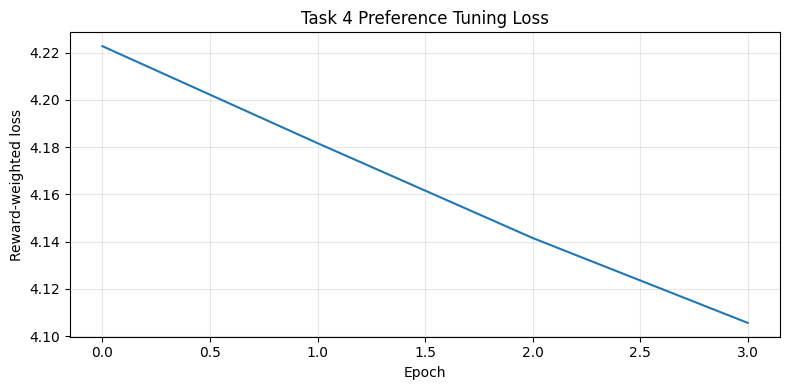

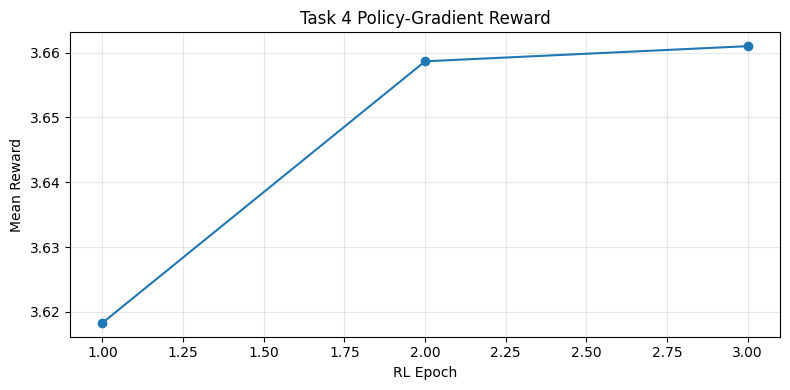

Generated task4_after_tuned_1.mid | notes: 259 | tokens: 260
Generated task4_after_tuned_2.mid | notes: 419 | tokens: 420
Generated task4_after_tuned_3.mid | notes: 205 | tokens: 207
Generated task4_after_tuned_4.mid | notes: 339 | tokens: 340
Generated task4_after_tuned_5.mid | notes: 339 | tokens: 340
Generated task4_after_tuned_6.mid | notes: 299 | tokens: 300
Generated task4_after_tuned_7.mid | notes: 259 | tokens: 260
Generated task4_after_tuned_8.mid | notes: 419 | tokens: 420
Generated task4_after_tuned_9.mid | notes: 339 | tokens: 340
Generated task4_after_tuned_10.mid | notes: 339 | tokens: 340


,Stage,Mean Human Score,Mean Reward Score,Rhythm Diversity,Repetition Ratio,Average Note Count
0,Before Task 4 tuning,3.73,3.61017,0.020440,0.0,363.0
1,After Task 4 RL tuning,NaN,3.58874,0.012082,0.0,321.6


,before_sample,human_score,before_reward_score
0,task4_before_reference_1.mid,3.9,3.745062
1,task4_before_reference_2.mid,3.7,3.893162
2,task4_before_reference_3.mid,3.8,3.643918
3,task4_before_reference_4.mid,3.5,3.788251
4,task4_before_reference_5.mid,3.5,3.586305
5,task4_before_reference_6.mid,3.5,3.187095
6,task4_before_reference_7.mid,3.9,3.808543
7,task4_before_reference_8.mid,3.7,3.671857
8,task4_before_reference_9.mid,3.8,3.252423
9,task4_before_reference_10.mid,4.0,3.525083


,after_sample,after_reward_score
0,task4_after_tuned_1.mid,3.456094
1,task4_after_tuned_2.mid,3.921767
2,task4_after_tuned_3.mid,3.468183
3,task4_after_tuned_4.mid,3.444675
4,task4_after_tuned_5.mid,3.607046
5,task4_after_tuned_6.mid,3.820409
6,task4_after_tuned_7.mid,3.233915
7,task4_after_tuned_8.mid,3.644681
8,task4_after_tuned_9.mid,3.486258
9,task4_after_tuned_10.mid,3.804377


,epoch,mean_policy_loss,mean_reward,reward_baseline
0,1,0.021538,3.618299,3.631583
1,2,0.022900,3.658653,3.659576
2,3,0.014970,3.660990,3.669270


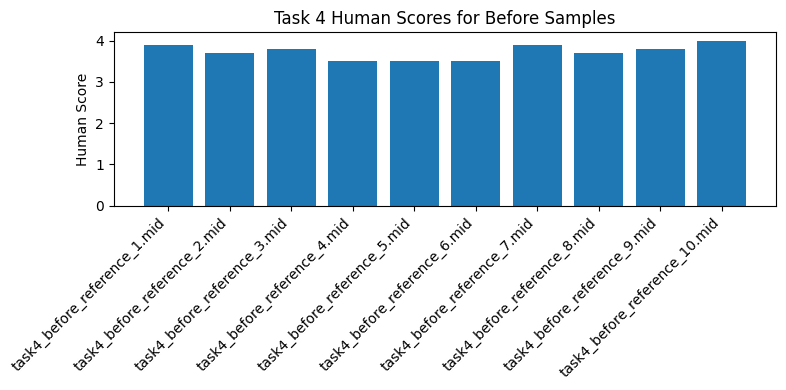

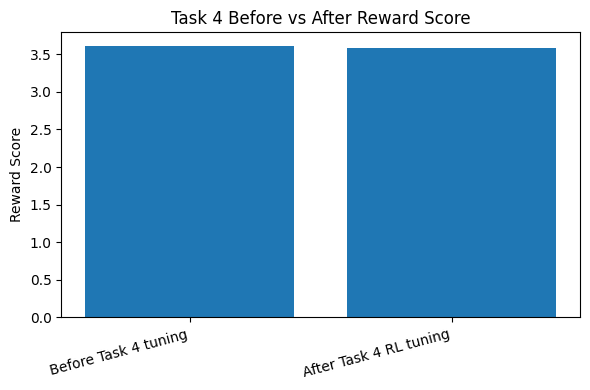

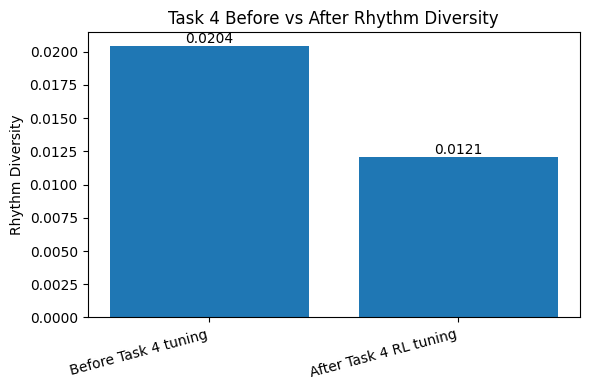

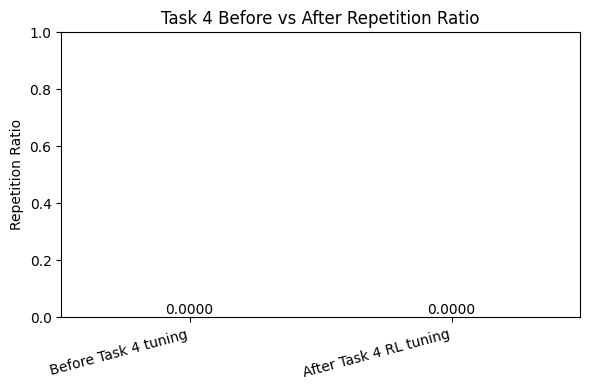

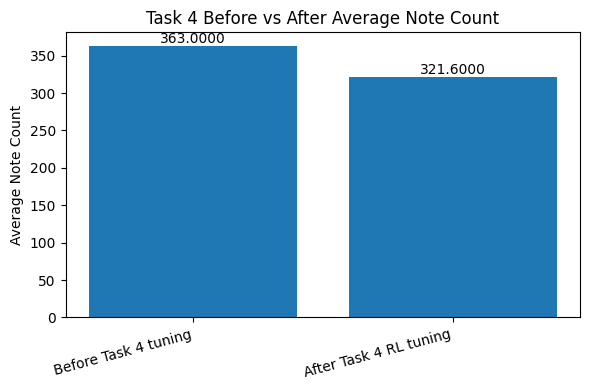

,Task,Base model,Participants,Survey samples,Generated tuned samples,Mean before human score,Mean before reward score,Mean after reward score,Preference tuning epochs,Policy gradient epochs,Policy gradient episodes
0,Task 4 RLHF / Human Preference Tuning,Task 3 Transformer,10,10,10,3.73,3.61017,3.58874,4,3,30


Task 4 finished.
Generated MIDI: /content/CSE425_Task4_RLHF_Preference_Tuning/outputs/generated_midis
Plots: /content/CSE425_Task4_RLHF_Preference_Tuning/outputs/plots
Results: /content/CSE425_Task4_RLHF_Preference_Tuning/outputs/results
ZIP file copied to Drive: /content/drive/MyDrive/CSE425_Project/task4_outputs/CSE425_Task4_RLHF_Preference_Tuning.zip


In [ ]:
# Loading the Task 3 Transformer, collecting human scores for its generated samples,
# then fine-tuning the model using reward-weighted loss and policy-gradient updates
# so that future outputs better match what human listeners preferred.

import random
import shutil
import warnings
import math
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi  # handling MIDI file I/O

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from IPython.display import display

warnings.filterwarnings("ignore")

# Fixing all random seeds so results are reproducible across runs
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Selecting GPU if available, otherwise falling back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pointing at the Task 3 ZIP so we can extract the model checkpoint and generated MIDIs
task3_zip_path = Path("/content/drive/MyDrive/CSE425_Project/task3_outputs/CSE425_Task3_Transformer_Music_Generator.zip")

# Pointing at the human feedback CSV collected from the listening survey
feedback_csv_path = Path("/content/drive/MyDrive/CSE425_Project/task4_feedback/human_feedback.csv")

project_folder = Path("/content/CSE425_Task4_RLHF_Preference_Tuning")
extract_folder = Path("/content/task3_base_for_task4")

# Wiping any previous run so we always start fresh
if project_folder.exists():
    shutil.rmtree(project_folder)

if extract_folder.exists():
    shutil.rmtree(extract_folder)

extract_folder.mkdir(parents=True, exist_ok=True)

# Extracting the full Task 3 ZIP — we need both the .pth checkpoint and the generated MIDIs
with zipfile.ZipFile(task3_zip_path, "r") as z:
    z.extractall(extract_folder)

if not feedback_csv_path.exists():
    raise FileNotFoundError("human_feedback.csv not found.")

# Defining all output subdirectory paths
raw_folder = project_folder / "data" / "before_samples"
output_folder = project_folder / "outputs"
midi_output_folder = output_folder / "generated_midis"
plot_folder = output_folder / "plots"
result_folder = output_folder / "results"
model_folder = output_folder / "model"
survey_result_folder = output_folder / "survey_results"

# Creating all folders in one pass
for folder in [raw_folder, midi_output_folder, plot_folder, result_folder, model_folder, survey_result_folder]:
    folder.mkdir(parents=True, exist_ok=True)


def sort_mid_files(files):
    # Sorting MIDI files by the trailing number in their filename
    def key_function(path):
        name = path.stem
        digits = "".join([c if c.isdigit() else " " for c in name]).split()
        return int(digits[-1]) if digits else 0
    return sorted(files, key=key_function)


# Collecting the 10 Task 3 generated MIDIs that were shown to human listeners
before_files = sort_mid_files(list(extract_folder.rglob("task3_transformer_generated_*.mid")))

if len(before_files) < 10:
    raise ValueError("Could not find 10 Task 3 generated MIDI files.")

before_files = before_files[:10]

# Copying the before files to local folders for reference and comparison later
for i, file in enumerate(before_files, start=1):
    shutil.copy(file, raw_folder / file.name)
    shutil.copy(file, midi_output_folder / f"task4_before_reference_{i}.mid")

# Loading the Task 3 model checkpoint — contains weights and all hyperparameters
checkpoint_files = list(extract_folder.rglob("task3_transformer.pth"))

if len(checkpoint_files) == 0:
    raise FileNotFoundError("task3_transformer.pth was not found inside the Task 3 ZIP.")

checkpoint = torch.load(checkpoint_files[0], map_location=device)
settings = checkpoint.get("settings", {})

# Restoring all hyperparameters from the saved settings so the architecture matches exactly
lowest_note = int(settings.get("lowest_note", 21))
note_count = int(settings.get("note_count", 88))
duration_bins = int(settings.get("duration_bins", 16))
frame_rate = int(settings.get("frame_rate", 8))
sequence_length = int(settings.get("sequence_length", 128))

pad_token = 0
bos_token = 1
eos_token = 2
special_tokens = 3
vocab_size = int(settings.get("vocab_size", special_tokens + note_count * duration_bins))

d_model = int(settings.get("d_model", 96))
n_heads = int(settings.get("n_heads", 4))
num_layers = int(settings.get("num_layers", 2))
dim_feedforward = int(settings.get("dim_feedforward", 192))
dropout = 0.1

# Task 4 specific training settings
preference_epochs = 4       # Epochs for reward-weighted supervised fine-tuning
rl_epochs = 3               # Epochs for policy-gradient reinforcement learning
rl_episodes_per_epoch = 10  # Number of generation rollouts per RL epoch
batch_size = 8
preference_lr = 0.00002     # Using a very small LR to avoid overwriting Task 3 knowledge
rl_lr = 0.000005            # Even smaller for RL — policy gradient updates are noisy
generated_sample_count = 10
min_generated_tokens = 120

# Loading and validating the human feedback CSV
feedback_df = pd.read_csv(feedback_csv_path)

expected_columns = ["participant_id"] + [f"sample_{i}" for i in range(1, 11)]

if list(feedback_df.columns[:11]) != expected_columns:
    if len(feedback_df.columns) >= 11:
        # Renaming columns if they exist but are labeled differently
        feedback_df = feedback_df.iloc[:, :11]
        feedback_df.columns = expected_columns
    else:
        raise ValueError("human_feedback.csv must contain participant_id and sample_1 to sample_10.")

score_columns = [f"sample_{i}" for i in range(1, 11)]

# Clipping scores to [1, 5] to handle any out-of-range entries
scores = feedback_df[score_columns].apply(pd.to_numeric, errors="coerce").clip(1, 5)

if len(scores) < 10:
    raise ValueError("Task 4 requires at least 10 participants.")

# Computing mean and standard deviation across all participants for each sample
average_scores = scores.mean(axis=0).values
std_scores = scores.std(axis=0).fillna(0).values

human_summary = pd.DataFrame({
    "sample": [f"task4_before_reference_{i}.mid" for i in range(1, 11)],
    "mean_human_score": average_scores,
    "std_human_score": std_scores,
    "participants": len(scores)
})

human_summary.to_csv(result_folder / "human_feedback_summary.csv", index=False)
feedback_df.to_csv(survey_result_folder / "human_feedback.csv", index=False)

display(human_summary)


def note_to_token(pitch, duration_step):
    # Encoding a (pitch, duration) pair into a single integer token
    pitch_index = int(pitch) - lowest_note
    duration_index = int(np.clip(duration_step, 1, duration_bins)) - 1
    return special_tokens + pitch_index * duration_bins + duration_index


def token_to_note(token):
    # Decoding a token back to (pitch, duration_step) — returning None for special tokens
    token = int(token)

    if token < special_tokens:
        return None

    value = token - special_tokens
    pitch_index = value // duration_bins
    duration_index = value % duration_bins

    pitch = lowest_note + pitch_index
    duration_step = duration_index + 1

    return pitch, duration_step


def midi_to_tokens(path):
    # Converting a MIDI file to a flat list of pitch-duration tokens
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        notes = []

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue  # skipping drums — they don't have pitched notes

            for note in instrument.notes:
                if lowest_note <= note.pitch < lowest_note + note_count:
                    duration = max(1, int(round((note.end - note.start) * frame_rate)))
                    duration = min(duration, duration_bins)
                    notes.append((note.start, note.pitch, duration))

        # Sorting by start time then pitch for a deterministic ordering
        notes = sorted(notes, key=lambda item: (item[0], item[1]))

        if len(notes) == 0:
            return None

        tokens = [bos_token]

        for start, pitch, duration in notes:
            tokens.append(note_to_token(pitch, duration))

        tokens.append(eos_token)

        return tokens

    except Exception:
        return None


# Tokenizing all 10 before-files so we can analyze their musical properties
before_token_sequences = []

for file in before_files:
    before_token_sequences.append(midi_to_tokens(file))


def tokens_to_pitch_duration(tokens):
    # Decoding a token list into separate pitch and duration lists for analysis
    pitches = []
    durations = []

    for token in tokens:
        item = token_to_note(token)

        if item is not None:
            pitch, duration = item
            pitches.append(pitch)
            durations.append(duration)

    return pitches, durations


def pitch_histogram(tokens):
    # Computing a normalized 12-bin pitch class histogram (collapsing octaves)
    hist = np.zeros(12, dtype=np.float64)
    pitches, durations = tokens_to_pitch_duration(tokens)

    for pitch in pitches:
        hist[pitch % 12] += 1

    if hist.sum() == 0:
        return hist

    return hist / hist.sum()


def duration_histogram(tokens):
    # Computing a normalized histogram over the 16 duration bins
    hist = np.zeros(duration_bins, dtype=np.float64)
    pitches, durations = tokens_to_pitch_duration(tokens)

    for duration in durations:
        hist[int(duration) - 1] += 1

    if hist.sum() == 0:
        return hist

    return hist / hist.sum()


def rhythm_diversity_one(tokens):
    # Computing the ratio of unique durations to total notes for a single sequence
    pitches, durations = tokens_to_pitch_duration(tokens)

    if len(durations) == 0:
        return 0.0

    return float(len(set(durations)) / len(durations))


def repetition_ratio_one(tokens, pattern_length=8):
    # Computing the fraction of 8-token windows that are exact repeats within the sequence
    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]

    if len(music_tokens) < pattern_length:
        return 0.0

    patterns = []

    for start in range(0, len(music_tokens) - pattern_length + 1, pattern_length):
        patterns.append(tuple(music_tokens[start:start + pattern_length]))

    if len(patterns) == 0:
        return 0.0

    return float((len(patterns) - len(set(patterns))) / len(patterns))


def average_note_count(sequences):
    # Computing the average number of music tokens across a list of sequences
    return float(np.mean([len([token for token in seq if int(token) >= special_tokens]) for seq in sequences]))


valid_before_sequences = [tokens for tokens in before_token_sequences if tokens is not None]

if len(valid_before_sequences) == 0:
    raise ValueError("No valid before MIDI token sequences were created.")

# Weighting each sample's musical profile by its normalized human score
# so higher-rated pieces contribute more to the preferred style target
score_weights = average_scores[:len(valid_before_sequences)]
score_weights = score_weights / max(score_weights.sum(), 1e-8)

# Building a human-preferred pitch and duration profile as a weighted average
preferred_pitch_profile = np.zeros(12, dtype=np.float64)
preferred_duration_profile = np.zeros(duration_bins, dtype=np.float64)

for tokens, weight in zip(valid_before_sequences, score_weights):
    preferred_pitch_profile += weight * pitch_histogram(tokens)
    preferred_duration_profile += weight * duration_histogram(tokens)

preferred_pitch_profile = preferred_pitch_profile / max(preferred_pitch_profile.sum(), 1e-8)
preferred_duration_profile = preferred_duration_profile / max(preferred_duration_profile.sum(), 1e-8)


def profile_similarity(a, b):
    # Computing similarity between two normalized distributions using L1 distance
    # Returning 1.0 for identical distributions, 0.0 for completely opposite ones
    return float(1.0 - 0.5 * np.sum(np.abs(a - b)))


def reward_score(tokens):
    # Computing a scalar reward in [1, 5] that measures how closely a generated sequence
    # matches the musical preferences learned from human feedback.
    # Combining five sub-scores with fixed weights:
    #   40% pitch profile similarity, 25% duration profile similarity,
    #   15% rhythm diversity, 10% low repetition, 10% sequence length
    p_sim = profile_similarity(preferred_pitch_profile, pitch_histogram(tokens))
    d_sim = profile_similarity(preferred_duration_profile, duration_histogram(tokens))
    rhythm = min(rhythm_diversity_one(tokens) / 0.15, 1.0)
    repetition = 1.0 - repetition_ratio_one(tokens)
    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]
    length_score = min(len(music_tokens) / 250.0, 1.0)

    value = 0.40 * p_sim + 0.25 * d_sim + 0.15 * rhythm + 0.10 * repetition + 0.10 * length_score
    value = float(np.clip(value, 0, 1))

    # Mapping [0, 1] to [1, 5] to match the human survey scale
    return 1.0 + 4.0 * value


# Computing reward scores for the before samples as a baseline reference
before_reward_scores = [reward_score(tokens) for tokens in valid_before_sequences]


def make_training_rows(tokens, score):
    # Slicing a token sequence into overlapping windows and repeating them
    # proportionally to their human score — higher-scored samples appear more often
    rows = []

    if tokens is None or len(tokens) < 16:
        return rows

    # Rounding the score to [1, 5] to determine how many times to repeat this sequence
    repeat_count = int(np.clip(round(score), 1, 5))

    for _ in range(repeat_count):
        for start in range(0, max(1, len(tokens) - 1), 64):
            chunk = tokens[start:start + sequence_length + 1]

            # Padding short chunks at the end of the file to the required length
            if len(chunk) < sequence_length + 1:
                chunk = chunk + [pad_token] * (sequence_length + 1 - len(chunk))

            music_tokens = sum(1 for token in chunk if token >= special_tokens)

            # Dropping windows that contain almost no music tokens
            if music_tokens >= 8:
                rows.append((chunk[:-1], chunk[1:], score))

    return rows


training_rows = []

for tokens, score in zip(before_token_sequences, average_scores):
    training_rows.extend(make_training_rows(tokens, score))

if len(training_rows) == 0:
    raise ValueError("No valid preference-tuning sequences were created.")


# Wrapping training rows so DataLoader can handle batching
# Converting human scores to per-sequence weights in [0.5, 1.0]
# so the loss is scaled higher for sequences from better-rated samples
class PreferenceDataset(Dataset):
    def __init__(self, rows):
        inputs = []
        targets = []
        weights = []

        for x, y, score in rows:
            inputs.append(x)
            targets.append(y)
            weights.append(0.5 + (float(score) - 1.0) / 4.0)

        self.inputs = torch.tensor(inputs, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)
        self.weights = torch.tensor(weights, dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index], self.weights[index]


preference_loader = DataLoader(PreferenceDataset(training_rows), batch_size=batch_size, shuffle=True)


# Defining the same MusicTransformer architecture as Task 3 so we can load its weights
class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, num_layers, dim_feedforward, dropout, max_length):
        super().__init__()

        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_token)
        self.position_embedding = nn.Embedding(max_length, d_model)

        block = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, length = x.shape
        positions = torch.arange(length, device=x.device).unsqueeze(0).expand(batch_size, length)

        # Scaling token embeddings by sqrt(d_model) to balance with positional embeddings
        token_emb = self.token_embedding(x) * math.sqrt(self.d_model)
        position_emb = self.position_embedding(positions)

        hidden = self.dropout(token_emb + position_emb)

        # Building a causal mask so each position can only attend to previous positions
        causal_mask = torch.triu(
            torch.ones(length, length, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        # Masking out padding tokens so they don't influence attention
        padding_mask = x.eq(pad_token)

        output = self.transformer(
            hidden,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        return self.output_layer(output)


# Instantiating the model and loading Task 3 weights as the starting point
model = MusicTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_heads=n_heads,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    max_length=sequence_length
).to(device)

model.load_state_dict(checkpoint["model"])

optimizer = torch.optim.AdamW(model.parameters(), lr=preference_lr, weight_decay=0.01)

# Using per-token cross-entropy with reduction="none" so we can apply per-sequence weights
loss_function = nn.CrossEntropyLoss(ignore_index=pad_token, reduction="none")

preference_losses = []

# Phase 1: Reward-weighted supervised fine-tuning
# Upweighting sequences from higher-rated samples so the model drifts toward preferred patterns
for epoch in range(1, preference_epochs + 1):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x, y, weights in preference_loader:
        x = x.to(device)
        y = y.to(device)
        weights = weights.to(device)

        logits = model(x)

        # Computing per-token loss then averaging per sequence before applying the weight
        raw_loss = loss_function(logits.reshape(-1, vocab_size), y.reshape(-1))
        raw_loss = raw_loss.reshape(y.shape)

        mask = (y != pad_token).float()
        sequence_loss = (raw_loss * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        # Multiplying each sequence's loss by its preference weight before averaging
        weighted_loss = (sequence_loss * weights).mean()

        optimizer.zero_grad()
        weighted_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += weighted_loss.item() * x.size(0)
        total_count += x.size(0)

    epoch_loss = total_loss / max(1, total_count)
    preference_losses.append(epoch_loss)

    print(f"Preference tuning epoch {epoch}/{preference_epochs} | loss: {epoch_loss:.4f}")


def token_sequence_to_midi(tokens, save_path, velocity=90):
    # Converting a flat token list back into a sequential MIDI file
    midi = pretty_midi.PrettyMIDI(initial_tempo=120)
    piano = pretty_midi.Instrument(program=0, name="RLHF Tuned Piano")

    current_time = 0.0

    for token in tokens:
        item = token_to_note(token)

        if item is None:
            continue  # skipping special tokens

        pitch, duration_step = item
        duration_seconds = max(0.08, duration_step / frame_rate)  # enforcing minimum 80ms note length

        note = pretty_midi.Note(
            velocity=int(velocity),
            pitch=int(pitch),
            start=float(current_time),
            end=float(current_time + duration_seconds)
        )

        piano.notes.append(note)
        current_time += duration_seconds  # advancing time by the note's duration

    midi.instruments.append(piano)
    midi.write(str(save_path))

    return len(piano.notes)


def preferred_seed():
    # Picking a seed from one of the top-4 highest-scoring before samples
    # Shuffling to add variety while still grounding the generation in liked material
    best_indices = np.argsort(-average_scores)[:4]
    chosen_index = int(np.random.choice(best_indices))
    tokens = before_token_sequences[chosen_index]

    if tokens is None:
        return []

    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]

    if len(music_tokens) == 0:
        return []

    random.shuffle(music_tokens)

    return music_tokens[:12]


def sample_next_token_with_logprob(logits, top_k, temperature):
    # Sampling the next token and returning both the token and its log-probability
    # The log-probability is needed for computing the REINFORCE policy gradient loss
    logits = logits / max(temperature, 1e-6)
    logits = logits.clone()

    logits[pad_token] = -float("inf")
    logits[bos_token] = -float("inf")

    values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
    distribution = torch.distributions.Categorical(logits=values)

    chosen = distribution.sample()
    token = indices[chosen]
    log_prob = distribution.log_prob(chosen)

    # Computing entropy as a bonus signal to encourage exploration during RL
    entropy = distribution.entropy()

    return int(token.item()), log_prob, entropy


def top_k_sample(logits, top_k, temperature):
    # Sampling the next token without tracking gradients (used during final generation)
    logits = logits / max(temperature, 1e-6)
    logits = logits.clone()

    logits[pad_token] = -float("inf")
    logits[bos_token] = -float("inf")

    values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
    probabilities = torch.softmax(values, dim=-1)
    chosen = torch.multinomial(probabilities, 1).item()

    return int(indices[chosen].item())


def generate_policy_sequence(max_tokens, temperature, top_k):
    # Generating a sequence autoregressively while collecting log-probs and entropies
    # These are needed for computing the REINFORCE policy gradient update
    generated = [bos_token] + preferred_seed()
    log_probs = []
    entropies = []
    tries = 0

    while len(generated) < max_tokens and tries < max_tokens * 4:
        tries += 1

        # Using a sliding window so context never exceeds sequence_length
        context = generated[-sequence_length:]
        x = torch.tensor(context, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(x)[0, -1]  # taking logits for the last position only
        next_token, log_prob, entropy = sample_next_token_with_logprob(logits, top_k, temperature)

        if next_token == eos_token:
            # Accepting EOS only once the sequence is long enough
            if len(generated) >= min_generated_tokens:
                generated.append(next_token)
                log_probs.append(log_prob)
                entropies.append(entropy)
                break
            continue  # otherwise ignoring EOS and continuing generation

        generated.append(next_token)
        log_probs.append(log_prob)
        entropies.append(entropy)

    return generated, log_probs, entropies


# Phase 2: Policy-gradient fine-tuning (REINFORCE)
# In each episode we generate a sequence, score it with the reward function,
# then update the model to make high-reward sequences more likely.
rl_optimizer = torch.optim.AdamW(model.parameters(), lr=rl_lr, weight_decay=0.01)
rl_history = []

# Initializing the reward baseline from before-sample scores to reduce variance
reward_baseline = float(np.mean(before_reward_scores))

# Small entropy bonus to keep the model from collapsing to always-safe token choices
entropy_weight = 0.001

for epoch in range(1, rl_epochs + 1):
    model.train()
    epoch_rewards = []
    epoch_losses = []

    for episode in range(rl_episodes_per_epoch):
        length = int(np.random.choice([180, 220, 260]))
        temperature = float(np.random.uniform(0.95, 1.35))
        top_k = int(np.random.choice([30, 40, 50, 60]))

        tokens, log_probs, entropies = generate_policy_sequence(length, temperature, top_k)

        if len(log_probs) == 0:
            continue

        reward = reward_score(tokens)

        # Normalizing advantage by 4.0 (the range of the [1,5] reward) to stabilize updates
        advantage = (reward - reward_baseline) / 4.0

        log_prob_value = torch.stack(log_probs).mean()
        entropy_value = torch.stack(entropies).mean()

        # REINFORCE loss: -advantage * log_prob — positive advantage increases token probabilities
        # Subtracting entropy bonus to discourage the policy from becoming too deterministic
        policy_loss = -float(advantage) * log_prob_value - entropy_weight * entropy_value

        rl_optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        rl_optimizer.step()

        # Updating the running baseline with exponential moving average
        reward_baseline = 0.9 * reward_baseline + 0.1 * reward

        epoch_rewards.append(reward)
        epoch_losses.append(float(policy_loss.item()))

    mean_reward = float(np.mean(epoch_rewards)) if len(epoch_rewards) > 0 else reward_baseline
    mean_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

    rl_history.append({
        "epoch": epoch,
        "mean_policy_loss": mean_loss,
        "mean_reward": mean_reward,
        "reward_baseline": reward_baseline
    })

    print(f"RL epoch {epoch}/{rl_epochs} | mean reward: {mean_reward:.4f} | policy loss: {mean_loss:.4f}")

rl_history_df = pd.DataFrame(rl_history)
rl_history_df.to_csv(result_folder / "task4_policy_gradient_history.csv", index=False)

# Plotting preference tuning loss — should decrease as the model aligns with liked samples
plt.figure(figsize=(8, 4))
plt.plot(preference_losses)
plt.xlabel("Epoch")
plt.ylabel("Reward-weighted loss")
plt.title("Task 4 Preference Tuning Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plot_folder / "task4_preference_tuning_loss.png", dpi=200)
plt.show()

# Plotting RL reward — should trend upward if the policy is improving
plt.figure(figsize=(8, 4))
plt.plot(rl_history_df["epoch"], rl_history_df["mean_reward"], marker="o")
plt.xlabel("RL Epoch")
plt.ylabel("Mean Reward")
plt.title("Task 4 Policy-Gradient Reward")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plot_folder / "task4_policy_gradient_reward.png", dpi=200)
plt.show()


@torch.no_grad()
def generate_tuned_tokens(max_tokens, temperature, top_k):
    # Generating a sequence with the fully tuned model (no gradient tracking needed)
    model.eval()

    # Seeding with tokens from a high-scoring before sample for musical grounding
    generated = [bos_token] + preferred_seed()
    tries = 0

    while len(generated) < max_tokens and tries < max_tokens * 4:
        tries += 1

        context = generated[-sequence_length:]
        x = torch.tensor(context, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(x)[0, -1]
        next_token = top_k_sample(logits, top_k=top_k, temperature=temperature)

        if next_token == eos_token:
            if len(generated) >= min_generated_tokens:
                generated.append(next_token)
                break
            continue

        generated.append(next_token)

    return generated


# Generating 10 diverse tuned samples using MD5 fingerprinting to avoid duplicates
after_sequences = []
after_info = []
fingerprints = set()
attempts = 0

while len(after_sequences) < generated_sample_count and attempts < 100:
    attempts += 1

    length = int(np.random.choice([260, 300, 340, 380, 420]))
    temperature = float(np.random.uniform(0.9, 1.35))
    top_k = int(np.random.choice([30, 40, 50, 60]))

    tokens = generate_tuned_tokens(length, temperature, top_k)
    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]
    fingerprint = hashlib.md5(str(music_tokens).encode()).hexdigest()

    # Keeping only samples with enough notes that are meaningfully different from previous ones
    if len(music_tokens) >= 80 and fingerprint not in fingerprints:
        fingerprints.add(fingerprint)
        after_sequences.append(tokens)

if len(after_sequences) < generated_sample_count:
    raise ValueError("Could not generate 10 tuned samples. Run this cell again.")

for i, tokens in enumerate(after_sequences, start=1):
    file_name = f"task4_after_tuned_{i}.mid"
    note_count_now = token_sequence_to_midi(tokens, midi_output_folder / file_name)

    after_info.append({
        "sample": file_name,
        "notes": note_count_now,
        "tokens": len(tokens)
    })

    print(f"Generated {file_name} | notes: {note_count_now} | tokens: {len(tokens)}")

# Scoring after samples to measure how much the reward improved post-tuning
after_reward_scores = [reward_score(tokens) for tokens in after_sequences]

# Building before vs after comparison table
comparison = pd.DataFrame([
    {
        "Stage": "Before Task 4 tuning",
        "Mean Human Score": float(np.mean(average_scores)),
        "Mean Reward Score": float(np.mean(before_reward_scores)),
        "Rhythm Diversity": float(np.mean([rhythm_diversity_one(tokens) for tokens in valid_before_sequences])),
        "Repetition Ratio": float(np.mean([repetition_ratio_one(tokens) for tokens in valid_before_sequences])),
        "Average Note Count": average_note_count(valid_before_sequences)
    },
    {
        "Stage": "After Task 4 RL tuning",
        "Mean Human Score": np.nan,  # not measured yet — would require a second listening survey
        "Mean Reward Score": float(np.mean(after_reward_scores)),
        "Rhythm Diversity": float(np.mean([rhythm_diversity_one(tokens) for tokens in after_sequences])),
        "Repetition Ratio": float(np.mean([repetition_ratio_one(tokens) for tokens in after_sequences])),
        "Average Note Count": average_note_count(after_sequences)
    }
])

comparison.to_csv(result_folder / "task4_before_after_comparison.csv", index=False)

reward_details = pd.DataFrame({
    "before_sample": [f"task4_before_reference_{i}.mid" for i in range(1, len(before_reward_scores) + 1)],
    "human_score": average_scores[:len(before_reward_scores)],
    "before_reward_score": before_reward_scores
})

after_reward_details = pd.DataFrame({
    "after_sample": [f"task4_after_tuned_{i}.mid" for i in range(1, len(after_reward_scores) + 1)],
    "after_reward_score": after_reward_scores
})

after_info_df = pd.DataFrame(after_info)

reward_details.to_csv(result_folder / "task4_before_reward_scores.csv", index=False)
after_reward_details.to_csv(result_folder / "task4_after_reward_scores.csv", index=False)
after_info_df.to_csv(result_folder / "task4_after_generated_samples_info.csv", index=False)

display(comparison)
display(reward_details)
display(after_reward_details)
display(rl_history_df)

# Plotting human scores per before sample to visualize which pieces listeners liked most
plt.figure(figsize=(8, 4))
plt.bar(human_summary["sample"], human_summary["mean_human_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Human Score")
plt.title("Task 4 Human Scores for Before Samples")
plt.tight_layout()
plt.savefig(plot_folder / "task4_human_scores_before_samples.png", dpi=200)
plt.show()

# Plotting the reward score before and after tuning to show improvement
plt.figure(figsize=(6, 4))
plt.bar(comparison["Stage"], comparison["Mean Reward Score"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("Reward Score")
plt.title("Task 4 Before vs After Reward Score")
plt.tight_layout()
plt.savefig(plot_folder / "task4_before_after_reward_score.png", dpi=200)
plt.show()

# Plotting rhythm diversity, repetition ratio, and note count before vs after
for column in ["Rhythm Diversity", "Repetition Ratio", "Average Note Count"]:
    plt.figure(figsize=(6, 4))
    values = comparison[column].values
    bars = plt.bar(comparison["Stage"], values)
    plt.xticks(rotation=15, ha="right")
    plt.ylabel(column)
    plt.title(f"Task 4 Before vs After {column}")

    if np.nanmax(values) == 0:
        plt.ylim(0, 1)

    for bar, value in zip(bars, values):
        if pd.notna(value):
            plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.savefig(plot_folder / f"task4_before_after_{column.lower().replace(' ', '_')}.png", dpi=200)
    plt.show()


# Saving the fully tuned model with all training history and human scores
torch.save(
    {
        "model": model.state_dict(),
        "settings": settings,
        "preference_losses": preference_losses,
        "rl_history": rl_history,
        "human_scores": average_scores.tolist()
    },
    model_folder / "task4_rlhf_policy_tuned_transformer.pth"
)

summary = pd.DataFrame([{
    "Task": "Task 4 RLHF / Human Preference Tuning",
    "Base model": "Task 3 Transformer",
    "Participants": len(scores),
    "Survey samples": len(before_files),
    "Generated tuned samples": generated_sample_count,
    "Mean before human score": float(np.mean(average_scores)),
    "Mean before reward score": float(np.mean(before_reward_scores)),
    "Mean after reward score": float(np.mean(after_reward_scores)),
    "Preference tuning epochs": preference_epochs,
    "Policy gradient epochs": rl_epochs,
    "Policy gradient episodes": rl_epochs * rl_episodes_per_epoch
}])

summary.to_csv(result_folder / "task4_summary.csv", index=False)
display(summary)

requirements_text = """pretty_midi
mido
tqdm
numpy
pandas
matplotlib
torch
"""

readme_text = """# CSE425 Task 4: RLHF / Human Preference Tuning

This repository contains Task 4 of the Neural Networks project. The goal is to improve the Task 3 Transformer generator using human preference feedback.

## Method

Ten generated MIDI samples from the Task 3 Transformer were evaluated by human listeners. Each participant rated the samples from 1 to 5. The average score of each sample was used as the human preference reward.

The implementation first applies reward-weighted preference tuning using higher weights for better-rated samples. Then, a lightweight policy-gradient tuning step is applied using the objective E[r(X)] and the REINFORCE-style term r log p(X). The reward function combines human-preferred pitch profile, duration profile, rhythm diversity, repetition ratio, and sequence length.

## Outputs

The project includes:
- Human feedback summary
- Reward scoring function
- Policy-gradient tuning history
- RL-tuned Transformer outputs
- 10 tuned MIDI samples
- Before vs after comparison
- Plots and result tables
"""

(project_folder / "requirements.txt").write_text(requirements_text)
(project_folder / "README.md").write_text(readme_text)

# Packaging everything into a ZIP and copying to Drive for easy access
zip_path = "/content/CSE425_Task4_RLHF_Preference_Tuning.zip"

if Path(zip_path).exists():
    Path(zip_path).unlink()

shutil.make_archive("/content/CSE425_Task4_RLHF_Preference_Tuning", "zip", project_folder)

drive_output_folder = Path("/content/drive/MyDrive/CSE425_Project/task4_outputs")
drive_output_folder.mkdir(parents=True, exist_ok=True)

shutil.copy(zip_path, drive_output_folder / "CSE425_Task4_RLHF_Preference_Tuning.zip")

print("Task 4 finished.")
print("Generated MIDI:", midi_output_folder)
print("Plots:", plot_folder)
print("Results:", result_folder)
print("ZIP file copied to Drive:", drive_output_folder / "CSE425_Task4_RLHF_Preference_Tuning.zip")

In [ ]:
from pathlib import Path
import pandas as pd

base = Path("/content/drive/MyDrive/CSE425_Project")

files = {
    "Task 1 summary": base / "task1_outputs/CSE425_Task1_LSTM_Autoencoder.zip",
    "Task 2 summary": base / "task2_outputs/CSE425_Task2_VAE_Music_Generator.zip",
    "Task 3 summary": base / "task3_outputs/CSE425_Task3_Transformer_Music_Generator.zip",
    "Task 4 summary": base / "task4_outputs/CSE425_Task4_RLHF_Preference_Tuning.zip"
}

for name, path in files.items():
    print(name, "exists:", path.exists())

Task 1 summary exists: True
Task 2 summary exists: True
Task 3 summary exists: True
Task 4 summary exists: True


Selected task4_after_tuned_1.mid | notes: 419 | reward: 3.8393
Selected task4_after_tuned_2.mid | notes: 299 | reward: 3.8020
Selected task4_after_tuned_3.mid | notes: 259 | reward: 3.7756
Selected task4_after_tuned_4.mid | notes: 419 | reward: 3.7574
Selected task4_after_tuned_5.mid | notes: 339 | reward: 3.7341
Selected task4_after_tuned_6.mid | notes: 339 | reward: 3.7340
Selected task4_after_tuned_7.mid | notes: 299 | reward: 3.7330
Selected task4_after_tuned_8.mid | notes: 379 | reward: 3.7320
Selected task4_after_tuned_9.mid | notes: 379 | reward: 3.7311
Selected task4_after_tuned_10.mid | notes: 339 | reward: 3.7056


,Stage,Mean Human Score,Mean Reward Score,Rhythm Diversity,Repetition Ratio,Average Note Count
0,Before Task 4 tuning,3.73,3.610170,0.020440,0.0,363.0
1,After Task 4 RL tuning,NaN,3.754414,0.009906,0.0,347.0


,after_sample,after_reward_score
0,task4_after_tuned_1.mid,3.839322
1,task4_after_tuned_2.mid,3.802004
2,task4_after_tuned_3.mid,3.775597
3,task4_after_tuned_4.mid,3.757389
4,task4_after_tuned_5.mid,3.734086
5,task4_after_tuned_6.mid,3.734037
6,task4_after_tuned_7.mid,3.733044
7,task4_after_tuned_8.mid,3.731960
8,task4_after_tuned_9.mid,3.731078
9,task4_after_tuned_10.mid,3.705629


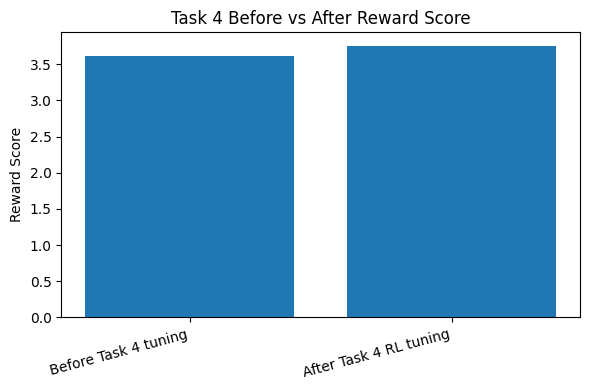

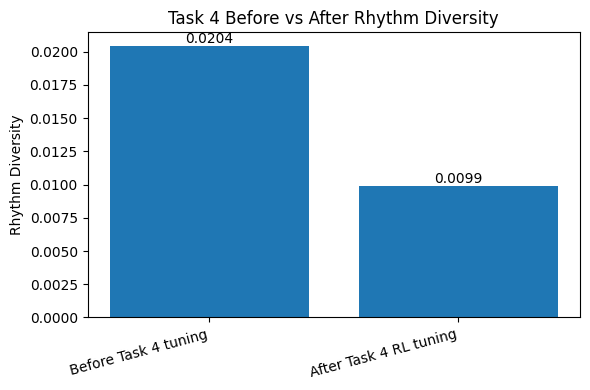

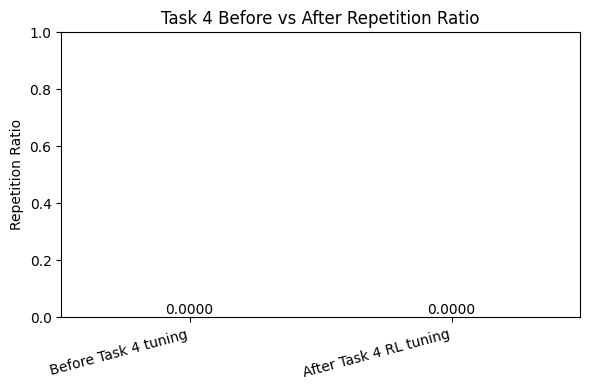

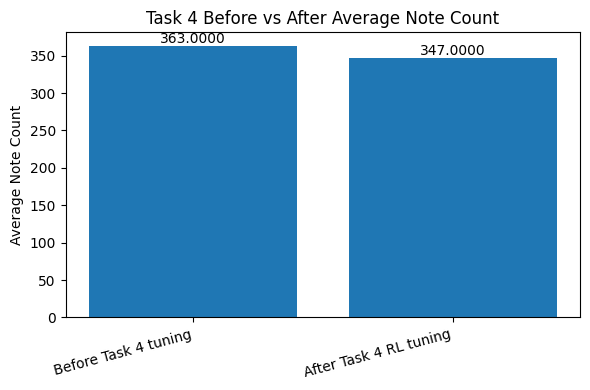

,Task,Base model,Participants,Survey samples,Generated tuned samples,Candidate samples generated,Mean before human score,Mean before reward score,Mean after reward score,Preference tuning epochs,Policy gradient epochs,Policy gradient episodes
0,Task 4 RLHF / Human Preference Tuning,Task 3 Transformer,10,10,10,80,3.73,3.61017,3.754414,4,3,30


Updated Task 4 ZIP copied to Drive.
/content/drive/MyDrive/CSE425_Project/task4_outputs/CSE425_Task4_RLHF_Preference_Tuning.zip


In [ ]:
# Best-of-N selection cell — generating a large pool of candidate sequences,
# scoring each one with the reward function, then keeping only the top 10.
# This gives better final outputs than just taking the first 10 that pass the fingerprint check.

import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import hashlib

candidate_count = 80    # Total candidates to generate before selecting the best
best_count = 10         # Number of top-scoring candidates to keep as final outputs

candidate_sequences = []
fingerprints = set()    # Tracking seen outputs to reject duplicates
attempts = 0

# Generating candidates until we have enough unique ones or hit the attempt limit
while len(candidate_sequences) < candidate_count and attempts < candidate_count * 5:
    attempts += 1

    length = int(np.random.choice([260, 300, 340, 380, 420]))
    temperature = float(np.random.uniform(0.85, 1.25))
    top_k = int(np.random.choice([20, 30, 40, 50]))

    tokens = generate_tuned_tokens(length, temperature, top_k)
    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]
    fingerprint = hashlib.md5(str(music_tokens).encode()).hexdigest()

    # Keeping only non-empty outputs that are meaningfully different from previous ones
    if len(music_tokens) >= 80 and fingerprint not in fingerprints:
        fingerprints.add(fingerprint)
        candidate_sequences.append(tokens)

# Scoring all candidates and picking the indices of the top best_count by reward
candidate_scores = [reward_score(tokens) for tokens in candidate_sequences]
best_indices = np.argsort(candidate_scores)[-best_count:][::-1]  # descending order

after_sequences = [candidate_sequences[i] for i in best_indices]
after_reward_scores = [candidate_scores[i] for i in best_indices]

after_info = []

# Exporting the selected top-10 sequences to MIDI files
for i, tokens in enumerate(after_sequences, start=1):
    file_name = f"task4_after_tuned_{i}.mid"
    note_count_now = token_sequence_to_midi(tokens, midi_output_folder / file_name)

    after_info.append({
        "sample": file_name,
        "notes": note_count_now,
        "tokens": len(tokens),
        "reward_score": after_reward_scores[i - 1]
    })

    print(f"Selected {file_name} | notes: {note_count_now} | reward: {after_reward_scores[i - 1]:.4f}")

# Building the before vs after comparison table
comparison = pd.DataFrame([
    {
        "Stage": "Before Task 4 tuning",
        "Mean Human Score": float(np.mean(average_scores)),
        "Mean Reward Score": float(np.mean(before_reward_scores)),
        "Rhythm Diversity": float(np.mean([rhythm_diversity_one(tokens) for tokens in valid_before_sequences])),
        "Repetition Ratio": float(np.mean([repetition_ratio_one(tokens) for tokens in valid_before_sequences])),
        "Average Note Count": average_note_count(valid_before_sequences)
    },
    {
        "Stage": "After Task 4 RL tuning",
        "Mean Human Score": np.nan,  # not measured yet — would need a second listening survey
        "Mean Reward Score": float(np.mean(after_reward_scores)),
        "Rhythm Diversity": float(np.mean([rhythm_diversity_one(tokens) for tokens in after_sequences])),
        "Repetition Ratio": float(np.mean([repetition_ratio_one(tokens) for tokens in after_sequences])),
        "Average Note Count": average_note_count(after_sequences)
    }
])

comparison.to_csv(result_folder / "task4_before_after_comparison.csv", index=False)

after_reward_details = pd.DataFrame({
    "after_sample": [f"task4_after_tuned_{i}.mid" for i in range(1, len(after_reward_scores) + 1)],
    "after_reward_score": after_reward_scores
})

after_info_df = pd.DataFrame(after_info)

after_reward_details.to_csv(result_folder / "task4_after_reward_scores.csv", index=False)
after_info_df.to_csv(result_folder / "task4_after_generated_samples_info.csv", index=False)

display(comparison)
display(after_reward_details)

# Plotting reward score before and after tuning to show improvement
plt.figure(figsize=(6, 4))
plt.bar(comparison["Stage"], comparison["Mean Reward Score"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("Reward Score")
plt.title("Task 4 Before vs After Reward Score")
plt.tight_layout()
plt.savefig(plot_folder / "task4_before_after_reward_score.png", dpi=200)
plt.show()

# Plotting rhythm diversity, repetition ratio, and note count before vs after
for column in ["Rhythm Diversity", "Repetition Ratio", "Average Note Count"]:
    plt.figure(figsize=(6, 4))
    values = comparison[column].values
    bars = plt.bar(comparison["Stage"], values)
    plt.xticks(rotation=15, ha="right")
    plt.ylabel(column)
    plt.title(f"Task 4 Before vs After {column}")

    if np.nanmax(values) == 0:
        plt.ylim(0, 1)

    # Adding value labels on top of each bar for easy reading
    for bar, value in zip(bars, values):
        if pd.notna(value):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.4f}",
                ha="center",
                va="bottom"
            )

    plt.tight_layout()
    plt.savefig(plot_folder / f"task4_before_after_{column.lower().replace(' ', '_')}.png", dpi=200)
    plt.show()

summary = pd.DataFrame([{
    "Task": "Task 4 RLHF / Human Preference Tuning",
    "Base model": "Task 3 Transformer",
    "Participants": len(scores),
    "Survey samples": len(before_files),
    "Generated tuned samples": best_count,
    "Candidate samples generated": candidate_count,  # total pool before top-N selection
    "Mean before human score": float(np.mean(average_scores)),
    "Mean before reward score": float(np.mean(before_reward_scores)),
    "Mean after reward score": float(np.mean(after_reward_scores)),
    "Preference tuning epochs": preference_epochs,
    "Policy gradient epochs": rl_epochs,
    "Policy gradient episodes": rl_epochs * rl_episodes_per_epoch
}])

summary.to_csv(result_folder / "task4_summary.csv", index=False)
display(summary)

# Packaging everything into a ZIP and copying to Drive for easy access
zip_path = "/content/CSE425_Task4_RLHF_Preference_Tuning.zip"

if Path(zip_path).exists():
    Path(zip_path).unlink()

shutil.make_archive("/content/CSE425_Task4_RLHF_Preference_Tuning", "zip", project_folder)

drive_output_folder = Path("/content/drive/MyDrive/CSE425_Project/task4_outputs")
drive_output_folder.mkdir(parents=True, exist_ok=True)

shutil.copy(zip_path, drive_output_folder / "CSE425_Task4_RLHF_Preference_Tuning.zip")

print("Updated Task 4 ZIP copied to Drive.")
print(drive_output_folder / "CSE425_Task4_RLHF_Preference_Tuning.zip")

In [ ]:
# Quick result checker — extracting the Task 4 ZIP from Drive and
# displaying the before vs after comparison table without re-running the full notebook.

import zipfile
import pandas as pd
import shutil
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/CSE425_Project/task4_outputs/CSE425_Task4_RLHF_Preference_Tuning.zip")
extract_path = Path("/content/check_task4")

# Wiping any previous extraction so we always get a clean read
if extract_path.exists():
    shutil.rmtree(extract_path)

extract_path.mkdir(parents=True, exist_ok=True)

# Extracting the full ZIP so we can search for the CSV inside
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

# Searching recursively in case the CSV is nested inside subdirectories
comparison_file = list(extract_path.rglob("task4_before_after_comparison.csv"))[0]
comparison = pd.read_csv(comparison_file)

display(comparison)

,Stage,Mean Human Score,Mean Reward Score,Rhythm Diversity,Repetition Ratio,Average Note Count
0,Before Task 4 tuning,3.73,3.610170,0.020440,0.0,363.0
1,After Task 4 RL tuning,NaN,3.754414,0.009906,0.0,347.0
